In [1]:
# ============================================================
# PROGETTO: ANALISI VENDITE E MODELLI PREDITTIVI
# Obiettivi:
# 1. Preparare e integrare i dataset
# 2. Stimare il profitto con:
#    - Regressione Lineare
#    - Random Forest
# 3. Stimare la quantità acquistata con un modello comportamentale
# 4. Confrontare i risultati in modo ordinato
# ============================================================

# =========================
# 0. IMPORT LIBRERIE
# =========================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, roc_auc_score
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
SAMPLE_SIZE_RF = 200000

# =========================
# 1. FUNZIONI DI SUPPORTO
# =========================
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Addestra il modello, genera previsioni e restituisce
    le metriche principali in formato dizionario.
    """
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    results = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2_Train": r2_score(y_train, y_pred_train),
        "R2_Test": r2_score(y_test, y_pred_test)
    }

    return model, results, y_pred_test


def plot_predicted_vs_actual(y_true, y_pred, title):
    """
    Scatter plot tra valori reali e predetti.
    """
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        linestyle="--"
    )
    plt.xlabel("Valore reale")
    plt.ylabel("Valore predetto")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(pipeline_model, numeric_features, categorical_features, title, top_n=10):
    """
    Estrae e visualizza le feature importance da una pipeline con:
    - preprocessor (ColumnTransformer)
    - model (RandomForestRegressor)
    """
    rf_model = pipeline_model.named_steps["model"]
    preprocessor = pipeline_model.named_steps["preprocessor"]

    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    all_feature_names = list(numeric_features) + list(cat_feature_names)

    importance_df = pd.DataFrame({
        "Variabile": all_feature_names,
        "Importanza": rf_model.feature_importances_
    }).sort_values(by="Importanza", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_df.head(top_n),
        x=importance_df.columns[1],  
        y=importance_df.columns[0],  
        hue=importance_df.columns[0],
        palette="viridis",
        legend=False
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Importanza")
    plt.ylabel("Variabile")
    plt.tight_layout()
    plt.show()

    return importance_df


# =========================
# 2. LOAD DATA
# =========================
calendar = pd.read_csv("calendar.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")
stores = pd.read_csv("stores.csv")


# =========================
# 3. TYPE CONVERSION
# =========================
sales["order_date"] = pd.to_datetime(sales["order_date"], errors="coerce")
customers["join_date"] = pd.to_datetime(customers["join_date"], errors="coerce")

# Trasformazione della loyalty in boolean
customers["loyalty_member"] = customers["loyalty_member"].astype(int).astype(bool)

# Conversione cocoa_percent da percentuale intera a quota decimale
products["cocoa_percent"] = products["cocoa_percent"] / 100


# =========================
# 4. DATA CLEANING STORES
# Correzione eventuali incoerenze city-country
# =========================
city_to_country = {
    "Sydney": "Australia",
    "New York": "USA",
    "London": "UK",
    "Toronto": "Canada",
    "Melbourne": "Australia",
    "Paris": "France",
    "Berlin": "Germany"
}

stores["country"] = stores["city"].map(city_to_country).fillna(stores["country"])

print("=== CITY / COUNTRY CORRETTI ===")
print(stores[["city", "country"]].drop_duplicates().sort_values("city"))


# =========================
# 5. MERGE DEI DATASET
# =========================
df = (
    sales
    .merge(products, on="product_id", how="left")
    .merge(stores, on="store_id", how="left")
    .merge(customers, on="customer_id", how="left")
)

print("\n=== SHAPE FINALE ===")
print(df.shape)

print("\n=== TOP MISSING VALUES DOPO IL MERGE ===")
print(df.isna().sum().sort_values(ascending=False).head(10))

=== CITY / COUNTRY CORRETTI ===
         city    country
2      Berlin    Germany
11     London         UK
1   Melbourne  Australia
0    New York        USA
3       Paris     France
4      Sydney  Australia
5     Toronto     Canada

=== SHAPE FINALE ===
(1000000, 24)

=== TOP MISSING VALUES DOPO IL MERGE ===
brand             9764
category          9764
weight_g          9764
cocoa_percent     9764
product_name      9764
loyalty_member       0
gender               0
age                  0
store_type           0
country              0
dtype: int64


In [2]:
# =========================
# 6. FEATURE ENGINEERING
# =========================

# Target ricostruito
df["profit_calc"] = (df["revenue"] - df["cost"]).round(2)

# Margine percentuale
df["margin_percentage"] = np.where(
    df["revenue"] != 0,
    (df["profit_calc"] / df["revenue"]) * 100,
    np.nan
).round(2)

# Variabili temporali
df["month"] = df["order_date"].dt.month
df["year"] = df["order_date"].dt.year
df["quarter"] = df["order_date"].dt.quarter
df["day_of_week"] = df["order_date"].dt.day_name()

# Customer tenure
raw_tenure = (df["order_date"] - df["join_date"]).dt.days

# Correzione robusta:
# se il tenure è negativo, lo consideriamo non valido e lo impostiamo a NaN
df["invalid_tenure"] = raw_tenure < 0
df["customer_tenure_days"] = raw_tenure.mask(raw_tenure < 0, np.nan)

# Variabili aggiuntive
df["is_discounted"] = df["discount"] > 0
df["avg_price_per_unit"] = np.where(
    df["quantity"] != 0,
    df["revenue"] / df["quantity"],
    np.nan
).round(2)

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=["<=25", "26-35", "36-50", "51-65", "65+"]
)

df["missing_product_info"] = df["product_name"].isna()

print("\n=== CONTROLLO TENURE ===")
print("Tenure negativi rilevati:", df["invalid_tenure"].sum())
print("Quota tenure negativi:", round(df["invalid_tenure"].mean() * 100, 2), "%")



=== CONTROLLO TENURE ===
Tenure negativi rilevati: 436931
Quota tenure negativi: 43.69 %


In [3]:
# =========================
# 7. MODELLO 1: LINEAR REGRESSION
# Target: profit_calc
# =========================
features_lr = [
    "quantity", "unit_price", "discount", "cocoa_percent", "weight_g",
    "age", "loyalty_member", "month", "year", "quarter",
    "customer_tenure_days", "missing_product_info", "brand",
    "category", "city", "country"
]

target_profit = "profit_calc"

X_lr = df[features_lr].copy()
y_lr = df[target_profit].copy()

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.33, random_state=RANDOM_STATE
)

num_cols_lr = [
    "quantity", "unit_price", "discount", "cocoa_percent", "weight_g",
    "age", "customer_tenure_days"
]

cat_cols_lr = [
    "brand", "category", "city", "country",
    "month", "year", "quarter",
    "loyalty_member", "missing_product_info"
]

num_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_lr = ColumnTransformer(transformers=[
    ("num", num_transformer_lr, num_cols_lr),
    ("cat", cat_transformer_lr, cat_cols_lr)
])

model_lr = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("model", LinearRegression())
])

model_lr, results_lr, y_pred_lr = evaluate_regression_model(
    model=model_lr,
    X_train=X_train_lr,
    X_test=X_test_lr,
    y_train=y_train_lr,
    y_test=y_test_lr,
    model_name="Linear Regression - Profit"
)

print("\n=== RISULTATI LINEAR REGRESSION ===")
for k, v in results_lr.items():
    if k == "Model":
        print(f"{k}: {v}")
    else:
        print(f"{k}: {v:.4f}")




=== RISULTATI LINEAR REGRESSION ===
Model: Linear Regression - Profit
MAE: 2.0340
RMSE: 2.6023
R2_Train: 0.8531
R2_Test: 0.8525



=== RISULTATI RANDOM FOREST ===
Model: Random Forest - Profit
MAE: 1.2806
RMSE: 1.7585
R2_Train: 0.9342
R2_Test: 0.9324


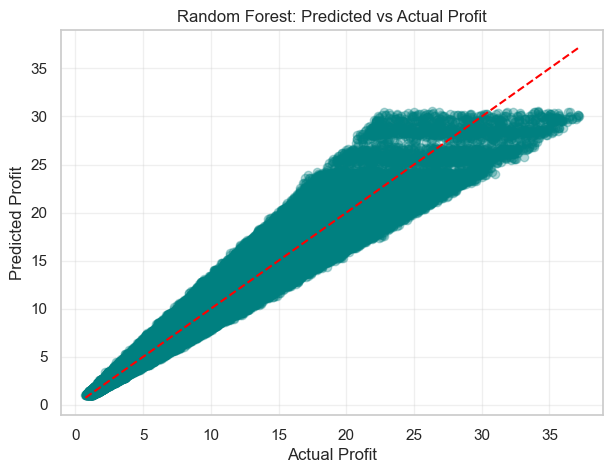

In [4]:
# =========================
# 8. MODELLO 2: RANDOM FOREST
# Target: profit_calc
# Nota:
# Campioniamo per velocizzare il training su dataset ampio
# =========================
df_model = df.sample(n=min(SAMPLE_SIZE_RF, len(df)), random_state=RANDOM_STATE).copy()

features_rf = [f for f in features_lr if f != "year"]
cat_cols_rf = [c for c in cat_cols_lr if c != "year"]
num_cols_rf = num_cols_lr.copy()  

X_rf = df_model[features_rf].copy()
y_rf = df_model[target_profit].copy()

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.33, random_state=RANDOM_STATE
)

# Cast esplicito delle categoriche per robustezza
for col in cat_cols_rf:
    X_train_rf.loc[:, col] = X_train_rf[col].astype(str)
    X_test_rf.loc[:, col] = X_test_rf[col].astype(str)

num_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_rf = ColumnTransformer(transformers=[
    ("num", num_transformer_rf, num_cols_rf),
    ("cat", cat_transformer_rf, cat_cols_rf)
])

model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestRegressor(
        n_estimators=30,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        max_samples=0.3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

model_rf, results_rf, y_pred_rf = evaluate_regression_model(
    model=model_rf,
    X_train=X_train_rf,
    X_test=X_test_rf,
    y_train=y_train_rf,
    y_test=y_test_rf,
    model_name="Random Forest - Profit"
)

print("\n=== RISULTATI RANDOM FOREST ===")
for k, v in results_rf.items():
    if k == "Model":
        print(f"{k}: {v}")
    else:
        print(f"{k}: {v:.4f}")


plt.figure(figsize=(7,5))
plt.scatter(y_test_rf, y_pred_rf, alpha=0.3, color='teal')
plt.plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], linestyle='--', color='red')
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Random Forest: Predicted vs Actual Profit")
plt.grid(alpha=0.3)
plt.show()

In [9]:
# =========================
# 9. MODELLO COMPORTAMENTALE
# =========================
# MODELLO COMPORTAMENTALE AVANZATO
# Target: High vs Low Quantity
# =========================
# -------------------------
# CREAZIONE TARGET SMART
# -------------------------
df_model['high_quantity'] = (df_model['quantity'] >= 3).astype(int)

# -------------------------
# FEATURE MIGLIORATE
# -------------------------
features_beh = [
    'age',
    'customer_tenure_days',
    'month',
    'day_of_week',
    'loyalty_member',
    'country',
    'brand',
    'category',
    'city',
    'is_discounted'
]

target_beh = 'high_quantity'

X_beh = df_model[features_beh].copy()
y_beh = df_model[target_beh].copy()

# -------------------------
# TRAIN TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_beh, y_beh,
    test_size=0.33,
    random_state=42,
    stratify=y_beh
)

# -------------------------
# COLONNE
# -------------------------
num_cols = ['age', 'customer_tenure_days', 'month']
cat_cols = [
    'day_of_week', 'loyalty_member', 'country',
    'brand', 'category', 'city', 'is_discounted'
]

# cast categoriche
for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# -------------------------
# PIPELINE
# -------------------------
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# -------------------------
# TRAINING
# -------------------------
model.fit(X_train, y_train)

# -------------------------
# VALUTAZIONE
# -------------------------
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("\n=== MODELLO COMPORTAMENTALE (HIGH VS LOW) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================
# 10. CONFRONTO FINALE MODELLI
# =========================
results_df = pd.DataFrame([results_lr, results_rf]) 

print("\n=== CONFRONTO FINALE MODELLI (PROFITTO) ===")
print(results_df.sort_values(by="R2_Test", ascending=False).round(4))



=== MODELLO COMPORTAMENTALE (HIGH VS LOW) ===
Accuracy: 0.5177
ROC AUC: 0.5031

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.42      0.41     26423
           1       0.60      0.58      0.59     39577

    accuracy                           0.52     66000
   macro avg       0.50      0.50      0.50     66000
weighted avg       0.52      0.52      0.52     66000


=== CONFRONTO FINALE MODELLI (PROFITTO) ===
                        Model     MAE    RMSE  R2_Train  R2_Test
1      Random Forest - Profit  1.2806  1.7585    0.9342   0.9324
0  Linear Regression - Profit  2.0340  2.6023    0.8531   0.8525


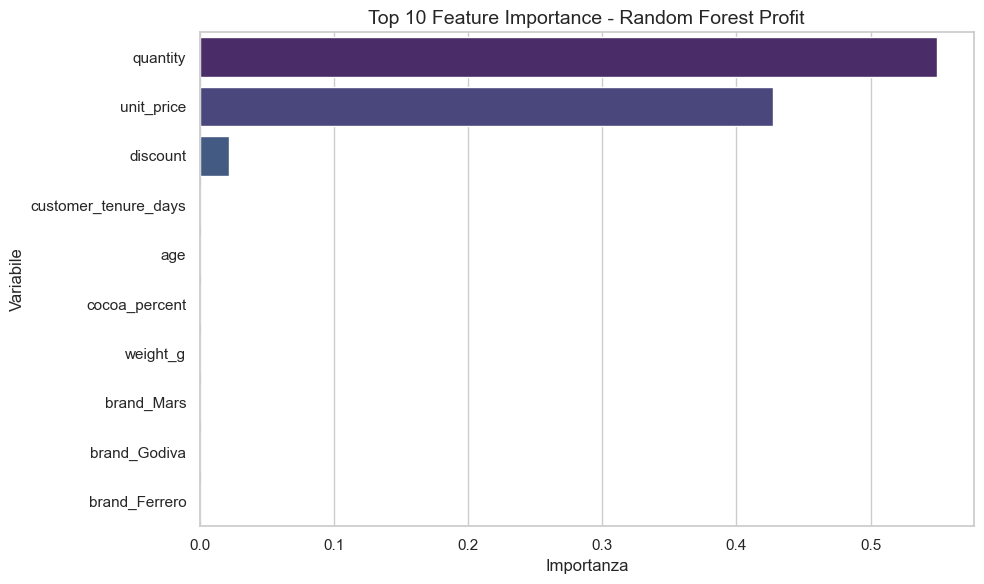


=== TOP 10 FEATURE IMPORTANCE - PROFIT ===
               Variabile  Importanza
0               quantity      0.5496
1             unit_price      0.4276
2               discount      0.0219
6   customer_tenure_days      0.0002
5                    age      0.0001
3          cocoa_percent      0.0001
4               weight_g      0.0001
12            brand_Mars      0.0000
9           brand_Godiva      0.0000
8          brand_Ferrero      0.0000


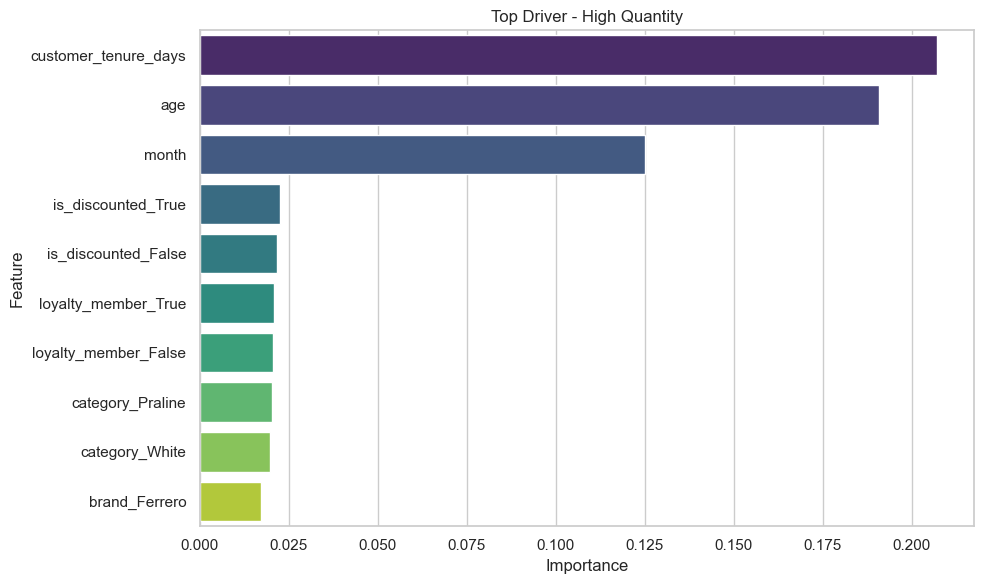

In [10]:
# =========================
# 11. FEATURE IMPORTANCE
# =========================
# 11A. Feature importance per il modello profitto
importance_profit = plot_feature_importance(
    pipeline_model=model_rf,
    numeric_features=num_cols_rf,
    categorical_features=cat_cols_rf,
    title="Top 10 Feature Importance - Random Forest Profit",
    top_n=10
)

print("\n=== TOP 10 FEATURE IMPORTANCE - PROFIT ===")
print(importance_profit.head(10).round(4))

# 11B. Feature importance per il modello comportamentale
rf_model = model.named_steps['model']
ohe = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']

cat_names = ohe.get_feature_names_out(cat_cols)
all_features = num_cols + list(cat_names)

df_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_imp.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    legend=False,
    palette='viridis'
)
plt.title("Top Driver - High Quantity")
plt.tight_layout()
plt.show()


=== HEAD CUSTOMER DF ===
  customer_id  recency  frequency  monetary  avg_quantity  avg_discount  \
0     C000001       25         25    481.16      2.840000      0.078000   
1     C000002       22         24    586.11      2.875000      0.060417   
2     C000003       45         24    678.37      3.000000      0.047917   
3     C000004       25         18    533.11      3.222222      0.019444   
4     C000005       11         32    811.12      2.812500      0.057813   

   avg_tenure   age  loyalty_member  
0         NaN  40.0            True  
1  790.333333  47.0           False  
2  498.500000  58.0            True  
3         NaN  25.0           False  
4  297.842105  43.0           False  


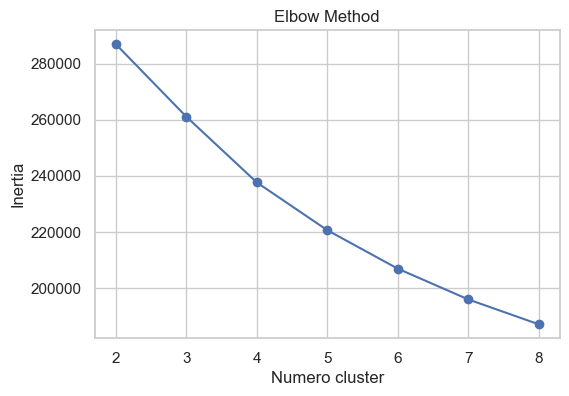


=== CLUSTER SUMMARY ===
         recency  frequency  monetary  avg_quantity  avg_discount  avg_tenure  \
cluster                                                                         
0          27.68      19.68    499.39          3.01          0.06      824.27   
1          25.15      17.56    420.51          2.88          0.06      261.46   
2          25.62      24.17    647.72          3.12          0.06      322.06   
3         108.16      16.78    427.41          3.02          0.06      384.67   

           age  
cluster         
0        44.19  
1        44.15  
2        44.00  
3        43.50  


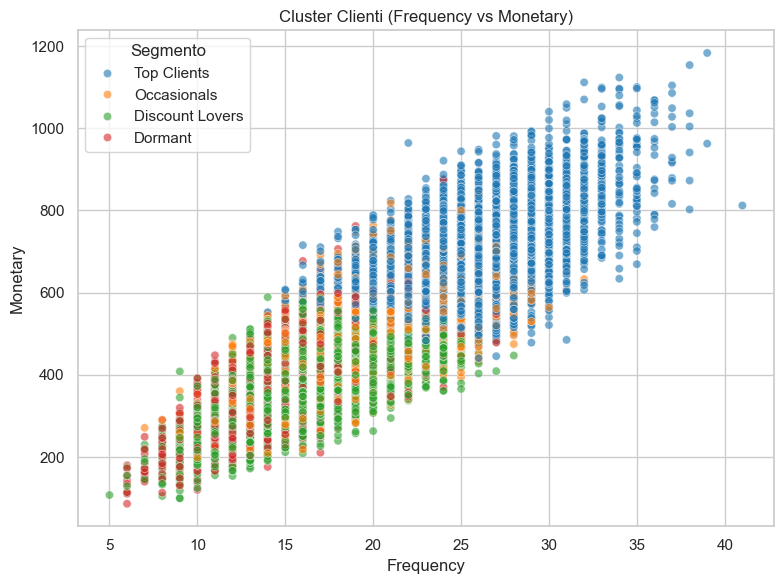

In [7]:
# =========================
# 12. CLUSTERING CLIENTI
# =========================

# Data di riferimento
reference_date = df['order_date'].max()

# Aggregazione per cliente
customer_df = df.groupby('customer_id').agg({

    # RFM
    'order_date': lambda x: (reference_date - x.max()).days,  # recency
    'order_id': 'nunique',                                   # frequency
    'revenue': 'sum',                                        # monetary

    # comportamento
    'quantity': 'mean',
    'discount': 'mean',

    # customer info
    'customer_tenure_days': 'mean',
    'age': 'mean',
    'loyalty_member': 'max'

}).reset_index()

# Rename colonne
customer_df.columns = [
    'customer_id',
    'recency',
    'frequency',
    'monetary',
    'avg_quantity',
    'avg_discount',
    'avg_tenure',
    'age',
    'loyalty_member'
]

print("\n=== HEAD CUSTOMER DF ===")
print(customer_df.head())

# PULIZIA E SCALING
features = [
    'recency',
    'frequency',
    'monetary',
    'avg_quantity',
    'avg_discount',
    'avg_tenure',
    'age'
]

X = customer_df[features].copy()

# gestiamo eventuali NaN
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# trovo numero ottimale di CLUSTER (k):
inertia = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Numero cluster")
plt.ylabel("Inertia")
plt.show()

k = 4  # puoi cambiare dopo l'elbow

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
customer_df['cluster'] = kmeans.fit_predict(X_scaled)

# analisi cluster:
print("\n=== CLUSTER SUMMARY ===")
cluster_summary = customer_df.groupby('cluster')[features].mean().round(2)
print(cluster_summary)

cluster_names = {
    0: 'Occasionals',
    1: 'Discount Lovers',
    2: 'Top Clients',
    3: 'Dormant'
}

customer_df['segment_name'] = customer_df['cluster'].map(cluster_names)

segment_order = ['Top Clients', 'Occasionals', 'Discount Lovers', 'Dormant']
customer_df['segment_name'] = pd.Categorical(
    customer_df['segment_name'],
    categories=segment_order,
    ordered=True
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=customer_df,
    x='frequency',
    y='monetary',
    hue='segment_name',
    palette='tab10',
    alpha=0.6
)
plt.title("Cluster Clienti (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend(title="Segmento")
plt.tight_layout()
plt.show()


In [8]:
# =========================
# 13. ESPORTAZIONE POWER BI
# =========================

# 1. Uniamo l'informazione del 'cluster' al dataset principale 'df'
# Usiamo il 'customer_id' e il dataframe CORRETTO ('customer_df')
df_powerbi = df.merge(customer_df[['customer_id', 'cluster']], on='customer_id', how='left')

# 2. Riempiamo eventuali valori nulli nel cluster (per i clienti che non avevano storico)
df_powerbi['cluster'] = df_powerbi['cluster'].fillna(-1)

# 3. Rinominiamo i cluster per renderli leggibili in Power BI
cluster_names_pb = {
    0: 'Occasionals',
    1: 'Discount Lovers',
    2: 'Top Clients',
    3: 'Dormant',
    -1: 'Non Classificato'
}
df_powerbi['Nome_Cluster'] = df_powerbi['cluster'].map(cluster_names_pb)

# 4. Esportiamo il file in CSV
# Nota: Uso sep=',' e decimal='.' che è lo standard internazionale.
df_powerbi.to_csv('dataset_per_powerbi.csv', index=False)

print("\nEsportazione completata! Il file 'dataset_per_powerbi.csv' è pronto nella tua cartella.")


Esportazione completata! Il file 'dataset_per_powerbi.csv' è pronto nella tua cartella.
